In [ ]:
import requests
import os
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd './drive/MyDrive/Dicoding/Project 3_2/'

/content/drive/MyDrive/Dicoding/Project 3_2


# **Scraping data**

In [ ]:
API_KEY = '49924295-e8fd19fa2a4f1df52f1a33f4f'
per_page = 200
total_pages = 200

def download_images(query, save_dir):
    for page_num in range(1, total_pages + 1):
        url = f'https://pixabay.com/api/?key={API_KEY}&q={query}&image_type=photo&per_page={per_page}&page={page_num}'
        response = requests.get(url)

        if response.status_code == 200:
            try:
                data = response.json()
                if data.get('hits'):
                    for i, result in enumerate(data['hits']):
                        image_url = result['webformatURL']
                        image_data = requests.get(image_url).content
                        with open(os.path.join(save_dir, f"{query.replace(' ','_')}_{page_num}_{i}.jpg"), 'wb') as f:
                            f.write(image_data)
            except ValueError:
                pass

## **1. Scraping Data Beach**

In [ ]:
query_beach = 'beach'
query_surfing ='surfing'
query_sailing ='sailing'
query_snorkeling ='snorkeling'
query_sunset_beach ='sunset beach'
save_dir_beach = './Dataset/beach'
if not os.path.exists(save_dir_beach):
    os.makedirs(save_dir_beach)

In [ ]:
download_images(query_sunset_beach, save_dir_beach)

## **2. Scraping Data Mountains**

In [ ]:
query_mountains = 'mountains'
query_hiking = 'hiking'
query_via_ferrata_climbing = 'via ferrata climbing'
query_limbing = 'mountain climbing'
query_campsite = 'campsite mountain'
query_forest = 'forest'
save_dir_mountains = './Dataset/mountains/'
if not os.path.exists(save_dir_mountains):
    os.makedirs(save_dir_mountains)

In [ ]:
download_images(query_forest, save_dir_mountains)

## **3. Scraping Data City**

In [ ]:
query_city = 'city'
query_downtown = 'downtown'
query_cityscape = 'cityscape'
query_city_street_view= 'city street view'
query_traffic = 'city traffic'
query_subway = 'subway station'
save_dir_city = './Dataset/city/'
if not os.path.exists(save_dir_city):
    os.makedirs(save_dir_city)

In [ ]:
download_images(query_subway, save_dir_city)

## **4. Scraping Data Desert**

In [ ]:
query_dry = 'dry desert'
query_desert = 'desert'
query_rocks = 'rocks in desert'
query_camels= 'camels in desert'
save_dir_desert = './Dataset/desert/'
if not os.path.exists(save_dir_desert):
    os.makedirs(save_dir_desert)

In [ ]:
download_images(query_camels, save_dir_desert)

# **Delete Gambar Corrupt**

In [ ]:
def delete_corrupt_image(directory):
  all_file = os.listdir(directory)
  total_file = len(all_file)
  remove = 0
  for filename in all_file:
    file_path = os.path.join(directory, filename)
    try:
      with Image.open(file_path) as img:
        img.verify()
    except(UnidentifiedImageError, OSError):
      os.remove(file_path)
      remove +=1
  total_after = total_file - remove
  print(f'file {directory} sebelum : {total_file}')
  print(f'file {directory} sesudah : {total_after}')

In [ ]:
directory = './Dataset/city/'
delete_corrupt_image(directory)

file ./Dataset/city/ sebelum : 2547
file ./Dataset/city/ sesudah : 2547


# **Rename Image**

In [ ]:
save_dir_desert = './Dataset/beach/'
if not os.path.exists(save_dir_desert):
    os.makedirs(save_dir_desert)

In [ ]:
def rename_images(folder_path, name):
    all_file = os.listdir(folder_path)
    for i, filename in enumerate(all_file):
        ext = os.path.splitext(filename)[1]
        new_name = f"{name}_{i}{ext}"
        old_path = os.path.join(folder_path, filename)
        new_path = os.path.join(folder_path, new_name)
        os.rename(old_path, new_path)

In [ ]:
rename_images('Dataset/city', 'city')
rename_images('Dataset/desert', 'desert')
rename_images('Dataset/beach', 'beach')
rename_images('Dataset/mountains', 'mountain')

In [ ]:
mountain = './Dataset/mountains/'
beach = './Dataset/beach/'
desert = './Dataset/desert/'
city = './Dataset/city/'

In [ ]:
all_file_desert = len(os.listdir(desert))
all_file_beach = len(os.listdir(beach))
all_file_city = len(os.listdir(city))
all_file_mountains = len(os.listdir(mountain))
jumlah_data_image = sum([all_file_desert, all_file_beach, all_file_city, all_file_mountains])
print(f'jumlah data : {jumlah_data_image}')


jumlah data : 10476


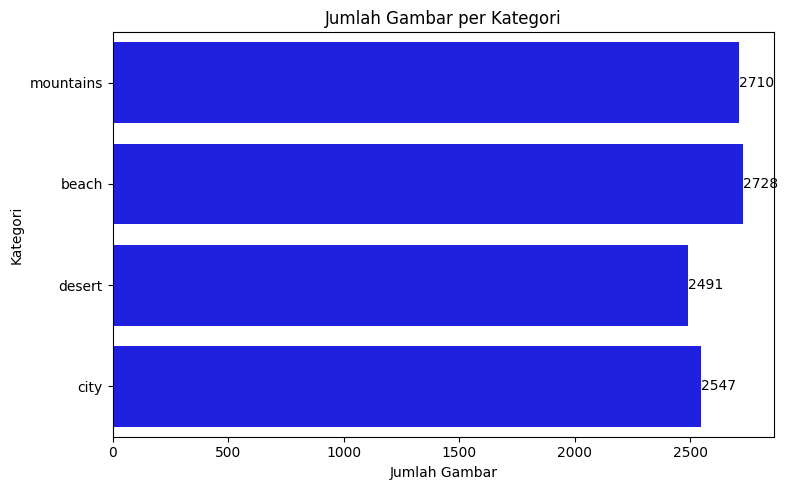

In [ ]:
kategori = ['mountains','beach', 'desert',  'city' ]
jumlah = [all_file_mountains, all_file_beach, all_file_desert, all_file_city]

plt.figure(figsize=(8, 5))
sns.barplot(x=jumlah, y=kategori, color='blue')

for i, v in enumerate(jumlah):
    plt.text(v + 1, i, str(v), va='center')

plt.title('Jumlah Gambar per Kategori')
plt.xlabel('Jumlah Gambar')
plt.ylabel('Kategori')

plt.tight_layout()
plt.show()
